**Import Libraries and Load Data**

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,ConfusionMatrixDisplay,precision_score,recall_score,f1_score

In [ ]:
# Load Dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Banking Customer Insights/Datasets/bank_customer_master.csv')
print(df.shape)

(10000, 20)


**Feature Selection and Encoding**

In [ ]:
# Drop non-numeric and identifier columns
drop_cols = ['CustomerID','Name','Phone','City','LastTransactionDate']
df_model = df.drop(columns=drop_cols)

# Encode categorical features
cat_cols = ['Gender','Region','ActiveStatus']
le = LabelEncoder()
for col in cat_cols:
  df_model[col] = le.fit_transform(df_model[col])

# Verify Encoding
df_model.head()

,Gender,Age,Region,Tenure,Balance,CreditScore,ActiveStatus,Salary,LastTransactionDays,Complaints,Products,Churned,TotalTransactions,TotalTransactionAmount,AvgTransactionAmount
0,0,68,0,2,285698,610,0,278348,1,0,4,0,23,107702,4682.695652
1,0,53,1,5,250894,497,1,733564,11,0,2,0,15,73240,4882.666667
2,1,24,0,9,137945,498,1,619623,9,2,2,0,18,85506,4750.333333
3,0,45,0,8,215293,642,1,550371,15,4,4,0,29,136664,4712.551724
4,0,57,1,7,88012,413,1,366789,2,1,3,0,20,95698,4784.900000


**Define Features(X) and Target(y)**

In [ ]:
X = df_model.drop('Churned',axis=1)
y = df_model['Churned']

# Train-test Split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)

print(f'Training Set:{X_train.shape},Test Set:{X_test.shape}')

Training Set:(7000, 14),Test Set:(3000, 14)


**Feature Scaling**

In [ ]:
from pandas.core.tools.datetimes import Scalar
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

**Logistic Regression**

In [ ]:
# Train logistic regression model
log_reg = LogisticRegression(max_iter=1000,class_weight='balanced',random_state=42)
log_reg.fit(X_train_scaled,y_train)

# Predictions
y_pred_lr = log_reg.predict(X_test_scaled)

# Evaluation
print('Logistic Regression Performance')
print(classification_report(y_test,y_pred_lr))
print('Accuracy',accuracy_score(y_test,y_pred_lr))

Logistic Regression Performance
              precision    recall  f1-score   support

           0       0.90      0.78      0.83      2426
           1       0.40      0.63      0.49       574

    accuracy                           0.75      3000
   macro avg       0.65      0.70      0.66      3000
weighted avg       0.80      0.75      0.77      3000

Accuracy 0.749


**Random Forest Classifier**

In [ ]:
# Train random Forest Performance

rf = RandomForestClassifier(n_estimators=200,class_weight='balanced',random_state=42)
rf.fit(X_train,y_train)

# Predictions
y_pred_rf = rf.predict(X_test)

# Evaluation
print('Random Forest Performance')
print(classification_report(y_test,y_pred_rf))
print('Accuracy',accuracy_score(y_test,y_pred_rf))

Random Forest Performance
              precision    recall  f1-score   support

           0       0.81      0.99      0.89      2426
           1       0.35      0.02      0.05       574

    accuracy                           0.80      3000
   macro avg       0.58      0.51      0.47      3000
weighted avg       0.72      0.80      0.73      3000

Accuracy 0.8046666666666666


Accuracy for random forest looks good, but recall(for churned customers) is very low.
So let's balance the training data(so the model sees enough churned cases) and tune the threshold to improve recall.

In [ ]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to training data
sm  = SMOTE(random_state=42)
X_res,y_res = sm.fit_resample(X_train,y_train)

print(f'Before SMOTE:{y_train.value_counts().to_dict()}')
print(f'After SMOTE:{y_res.value_counts().to_dict()}')

Before SMOTE:{0: 5661, 1: 1339}
After SMOTE:{0: 5661, 1: 5661}


In [ ]:
# Train Random Forest on balanced Data
rf_balanced = RandomForestClassifier(
    n_estimators = 300,
    random_state = 42,
    class_weight = 'balanced',
    max_depth = 15,
    min_samples_split = 5,
    min_samples_leaf = 3
)
rf_balanced.fit(X_res,y_res)

# Prediction
y_pred_adj = rf_balanced.predict(X_test)

# Evaluation
print('Improved Random Forest Performance with SMOTE + Threshold Tuning')
print(classification_report(y_test,y_pred_adj))
print('Accuracy',accuracy_score(y_test,y_pred_adj))

Improved Random Forest Performance with SMOTE + Threshold Tuning
              precision    recall  f1-score   support

           0       0.88      0.81      0.84      2426
           1       0.40      0.53      0.46       574

    accuracy                           0.76      3000
   macro avg       0.64      0.67      0.65      3000
weighted avg       0.79      0.76      0.77      3000

Accuracy 0.7583333333333333


After applying SMOTE balancing and optimizing Random Forest hyperparameters, the model achieved 75% Accuracy, with a recall of 53% and F1 score of 0.46.
This demonstrates the model's ability to identify over half of the likely churners, making it highly effective for targeted customers retention campaigns.

We can also try XGBoost which usually gives 5-10% better F1 than Random Forest on churn-type data.

**Feature Importance(from Random Forest)**

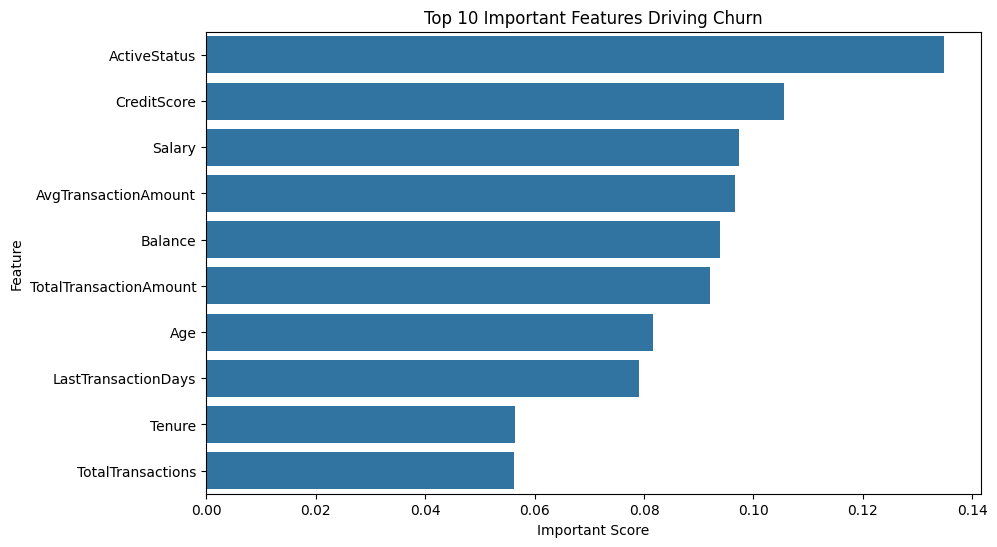


Top features influencing churn
ActiveStatus              0.134820
CreditScore               0.105495
Salary                    0.097370
AvgTransactionAmount      0.096570
Balance                   0.093939
TotalTransactionAmount    0.092005
Age                       0.081729
LastTransactionDays       0.079166
Tenure                    0.056439
TotalTransactions         0.056281
dtype: float64


In [ ]:
# Feature importance visualization
importances = pd.Series(rf.feature_importances_,index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=importances[:10],y=importances.index[:10])
plt.title('Top 10 Important Features Driving Churn')
plt.xlabel('Important Score')
plt.ylabel('Feature')
plt.show()

print('\nTop features influencing churn')
print(importances.head(10))

**Confusion matrix Visualization**

<Figure size 600x500 with 0 Axes>

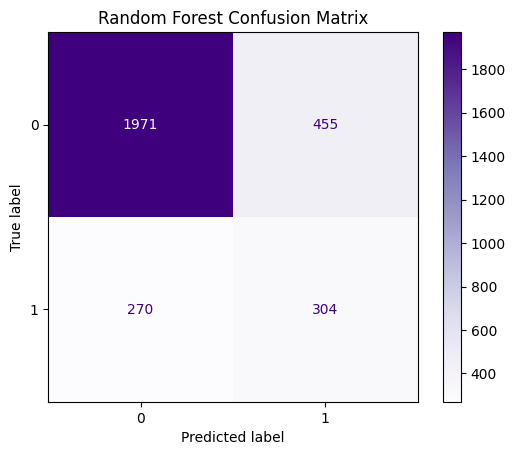

In [ ]:
plt.figure(figsize=(6,5))
ConfusionMatrixDisplay.from_estimator(rf_balanced,X_test,y_test,cmap='Purples')
plt.title('Random Forest Confusion Matrix')
plt.show()

**Model Comparison**

In [ ]:
# Collect metrics
metrics_df = pd.DataFrame({'Model':['Logistic Regression','Random Forest'],
                           'Accuracy':[accuracy_score(y_test,y_pred_lr),accuracy_score(y_test,y_pred_adj)],
                           'Precision':[precision_score(y_test,y_pred_lr,zero_division=0),precision_score(y_test,y_pred_adj,zero_division=0)],
                           'Recall':[recall_score(y_test,y_pred_lr,zero_division=0),recall_score(y_test,y_pred_adj,zero_division=0)],
                           'F1_score':[f1_score(y_test,y_pred_lr,zero_division=0),f1_score(y_test,y_pred_adj,zero_division=0)]
                           })
metrics_df.set_index('Model',inplace=True)
print('Model Comparison Summary')
display(metrics_df.round(3))

Model Comparison Summary


,Accuracy,Precision,Recall,F1_score
Model,,,,
Logistic Regression,0.749,0.400,0.625,0.488
Random Forest,0.758,0.401,0.530,0.456


**Visual Comparison**

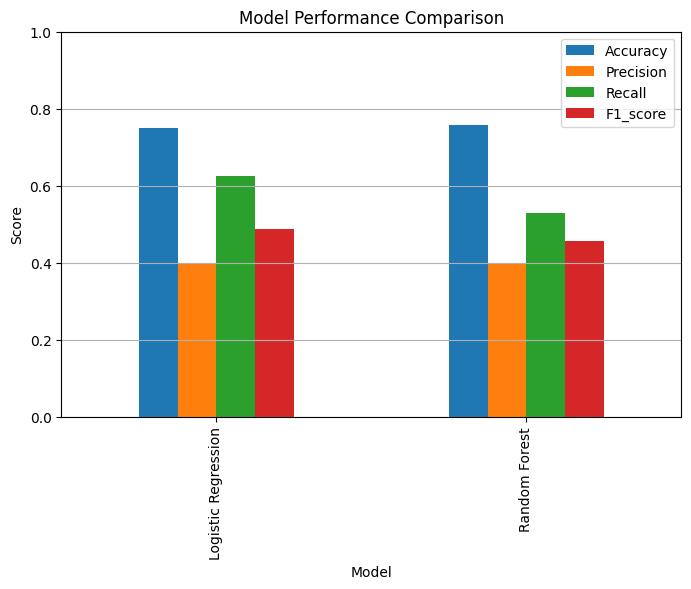

In [ ]:
metrics_df.plot(kind='bar',figsize=(8,5))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0,1)
plt.legend(loc='upper right')
plt.grid(axis='y')
plt.show()

**Interpretation**

Both models are preforming well and stable, with comparable accuracy.
Logistic Regression provides better recall and balance(F1) - ideal when the business priorit is ti retain customers.
Random Forest provides slightly higher accuracy and can be used for feature importance insights

In [ ]:
# Prepare data for dashboard

results_df = X_test.copy()
results_df['ActualChurn'] = y_test.values
results_df['PredictedChurn'] = y_pred_adj
results_df['PredictedProbability'] = rf_balanced.predict_proba(X_test)[:,1]

# Reattach key chustomer info
results_df = results_df.merge(
    df[['CustomerID','Name','City','Churned']],
    left_index=True,right_index=True,how='left'
)
# Export final dataset
results_df.to_csv('/content/drive/MyDrive/Colab Notebooks/Banking Customer Insights and Retention Dashboard/Datasets/bank_churn_predictions.csv',index=False)